# Kyiv Apartment Rent Price Prediction

**Course:** Introduction to Machine Learning  
**Project type:** Supervised learning / regression  
**Goal:** predict monthly apartment rent prices in Kyiv using property characteristics scraped from LUN.

This notebook is written as a reproducible final report: every step is commented and can be run from start to finish.

## 1. Problem Definition

The practical problem is to estimate apartment rental prices in Kyiv based on observable property characteristics. This is useful for tenants, landlords, real-estate platforms, and analysts who want to understand which factors are associated with higher or lower rent.

- **Prediction target:** monthly rent price in UAH.
- **Type of task:** regression.
- **Predictors:** apartment size, rooms, floor, district, construction technology, heating type, geographic coordinates, and other available characteristics.

Because rental prices are strongly right-skewed, the models are trained on `log_price`, but the final evaluation is also reported in UAH for easier interpretation.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Statistics
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import clone as sklearn_clone
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

import json
from shapely.geometry import Point, shape
from shapely.ops import unary_union
from shapely.prepared import prep

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost not found — install with: pip install xgboost")

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 19

## 2. Data Loading

The dataset contains apartment rental listings from Kyiv. Each row corresponds to one listing. The raw file includes prices in several currencies, apartment characteristics, location, and description text.

In [2]:
DATA_PATH = "data/kyiv_flats_enriched.csv"
raw = pd.read_csv(DATA_PATH)

print("Raw data shape:", raw.shape)
raw.head()

Raw data shape: (10362, 28)


,url,price,currency,address,rooms,area_total,area_living,area_kitchen,floor,total_floors,build_year,construction_tech,heating_type,lat,lon,district,commission,description,dist_metro_km,drive_time_maidan_car_min,drive_time_maidan_transit_min,dist_bus_stop_km,bank_side,dist_dnipro_km,dist_grocery_km,dist_supermarket_km,dist_school_km,dist_park_km
0,https://lun.ua/realty/4692693468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://lun.ua/realty/4661904752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://lun.ua/realty/4692392855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://lun.ua/realty/4677008472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://lun.ua/realty/4693824448,"34,000.00",UAH,"Круглоуніверситетська вулиця, 2/1",2.00,51.00,-,7,1,5.00,"1,937.00",цегляна технологія,централізоване опалення,50.44,30.52,Печерський,NaN,Квартира має роздільне планування та суміщений...,0.53,11.18,10.92,0.26,right,1.71,0.06,0.27,0.17,0.44


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10362 entries, 0 to 10361
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            10362 non-null  object 
 1   price                          10308 non-null  float64
 2   currency                       10308 non-null  object 
 3   address                        10016 non-null  object 
 4   rooms                          10307 non-null  float64
 5   area_total                     10308 non-null  float64
 6   area_living                    10255 non-null  object 
 7   area_kitchen                   10255 non-null  object 
 8   floor                          10308 non-null  object 
 9   total_floors                   10304 non-null  float64
 10  build_year                     8358 non-null   float64
 11  construction_tech              9438 non-null   object 
 12  heating_type                   9547 non-null  

In [4]:
# Missing values in raw data
missing_raw = raw.isna().sum().sort_values(ascending=False)
missing_raw

commission                       6882
build_year                       2004
district                         1439
construction_tech                 924
heating_type                      815
address                           346
lon                               337
dist_school_km                    337
dist_supermarket_km               337
dist_grocery_km                   337
dist_dnipro_km                    337
bank_side                         337
dist_bus_stop_km                  337
drive_time_maidan_transit_min     337
drive_time_maidan_car_min         337
dist_metro_km                     337
dist_park_km                      337
lat                               337
description                       137
area_kitchen                      107
area_living                       107
total_floors                       58
rooms                              55
price                              54
floor                              54
area_total                         54
currency    

## 3. Data Cleaning and Feature Engineering

The raw dataset requires several cleaning steps:

1. Remove duplicate listings by URL.
2. Remove observations with missing target values.
3. Convert all prices to UAH.
4. Convert numeric-looking columns stored as text into numeric format.
5. Create additional features such as building age and floor ratio.
6. Remove extreme or unrealistic outliers.

Currency conversion is based on fixed approximate exchange rates used for reproducibility. If the project is updated later, these rates can be replaced with official NBU rates for the exact scraping date.

In [5]:
df = raw.copy()

# 1. Remove duplicated listings
initial_rows = len(df)
df = df.drop_duplicates(subset=["url"])
print("Removed duplicated URLs:", initial_rows - len(df))

# 2. Drop rows where target or key features are missing.
#    Also require coordinates so all geospatial features are available.
df = df.dropna(subset=["price", "currency", "area_total", "rooms", "lat", "lon"])

# 3. Convert all prices into UAH
exchange_rates = {"UAH": 1.0, "USD": 45, "EUR": 51}
df["price_uah"] = df["price"] * df["currency"].map(exchange_rates)
df = df.dropna(subset=["price_uah"])

# 4. Convert numeric columns stored as text
for col in ["area_living", "area_kitchen", "floor"]:
    df[col] = pd.to_numeric(df[col].replace("-", np.nan), errors="coerce")

# 5. Feature engineering
df["has_commission"] = df["commission"].notna().astype(int)

df["building_age"] = 2026 - df["build_year"]
df.loc[(df["building_age"] < 0) | (df["building_age"] > 200), "building_age"] = np.nan

df["floor_ratio"] = df["floor"] / df["total_floors"]
df.loc[(df["floor_ratio"] <= 0) | (df["floor_ratio"] > 1.5), "floor_ratio"] = np.nan

# is_last_floor: 1 if apartment is on the top floor of the building
df["is_last_floor"] = (df["floor"] == df["total_floors"]).astype(int)

# price_per_sqm: alternative target used in Section 12
df["price_per_sqm"] = df["price_uah"] / df["area_total"]

print("Shape after basic cleaning:", df.shape)
df[["price", "currency", "price_uah", "rooms", "area_total", "floor", "total_floors", "is_last_floor"]].head()

Removed duplicated URLs: 0
Shape after basic cleaning: (10024, 34)


,price,currency,price_uah,rooms,area_total,floor,total_floors,is_last_floor
4,"34,000.00",UAH,"34,000.00",2.00,51.00,1.00,5.00,0
5,"20,000.00",UAH,"20,000.00",2.00,80.00,5.00,24.00,0
6,"2,300.00",USD,"103,500.00",3.00,87.00,27.00,30.00,0
7,"16,500.00",UAH,"16,500.00",1.00,35.00,1.00,9.00,0
8,"1,600.00",USD,"72,000.00",3.00,142.00,12.00,24.00,0


In [6]:
# District column cleaning
# The raw district field contains dirty values: street names, "Нова забудова", etc.
# We keep only the 10 official Kyiv districts; everything else is set to NaN.
KYIV_DISTRICTS = {
    "Голосіївський", "Дарницький", "Деснянський", "Дніпровський",
    "Оболонський", "Печерський", "Подільський", "Святошинський",
    "Солом'янський", "Шевченківський"
}

def clean_district(val):
    if pd.isna(val):
        return np.nan
    for d in KYIV_DISTRICTS:
        if str(val).startswith(d):
            return d
    return np.nan

df["district"] = df["district"].apply(clean_district)
print("District value counts after cleaning:")
print(df["district"].value_counts(dropna=False))

District value counts after cleaning:
district
NaN               6557
Печерський         975
Дніпровський       815
Шевченківський     601
Оболонський        369
Святошинський      332
Подільський        316
Голосіївський       57
Дарницький           2
Name: count, dtype: int64


In [7]:
df.columns

Index(['url', 'price', 'currency', 'address', 'rooms', 'area_total',
       'area_living', 'area_kitchen', 'floor', 'total_floors', 'build_year',
       'construction_tech', 'heating_type', 'lat', 'lon', 'district',
       'commission', 'description', 'dist_metro_km',
       'drive_time_maidan_car_min', 'drive_time_maidan_transit_min',
       'dist_bus_stop_km', 'bank_side', 'dist_dnipro_km', 'dist_grocery_km',
       'dist_supermarket_km', 'dist_school_km', 'dist_park_km', 'price_uah',
       'has_commission', 'building_age', 'floor_ratio', 'is_last_floor',
       'price_per_sqm'],
      dtype='object')

In [8]:
cols_to_check = ["url", "price_uah", "area_total", "rooms", "total_floors"]

outliers = df[
    ~((df["price_uah"] >= 3_000) &
      (df["price_uah"] <= 500_000) &
      (df["area_total"] >= 10) &
      (df["area_total"] <= 400) &
      (df["rooms"] >= 1) &
      (df["rooms"] <= 10) &
      (df["total_floors"] >= 1) &
      (df["total_floors"] <= 100))
][cols_to_check]

print("Аутлаєри (за вибраними колонками):")
outliers.head(20)

Аутлаєри (за вибраними колонками):


,url,price_uah,area_total,rooms,total_floors
92,https://lun.ua/realty/4675650412,"72,000.00","5,600.00",2.00,25.00
1955,https://lun.ua/realty/4675685569,"3,375,000.00",60.00,2.00,16.00
2767,https://lun.ua/realty/4683741224,"540,000.00",306.00,4.00,26.00
3041,https://lun.ua/realty/4521114360,"612,000.00",315.00,5.00,6.00
4088,https://lun.ua/realty/4693429046,"810,000.00",343.00,5.00,11.00
4151,https://lun.ua/realty/4653149268,"540,000.00",210.00,5.00,27.00
5209,https://lun.ua/realty/4608194313,"34,990.00",72.00,3.00,NaN
5880,https://lun.ua/realty/4668228498,"23,000.00",41.00,1.00,NaN
5898,https://lun.ua/realty/4661908271,"5,400,000.00",47.00,1.00,25.00
6120,https://lun.ua/realty/4643905287,"315,000.00",700.00,5.00,13.00


In [9]:
# Statistical outlier removal
# Price: 3-sigma rule applied on log scale (handles right-skewed distribution).
#   In linear space this keeps roughly exp(mean ± 3σ) — about ±20x the typical price.
# Area: 1st–99th percentile (removes extreme micro-studios and mansions).
# Rooms / floors: hard sensible limits.

log_price_tmp = np.log(df["price_uah"])
p_mean, p_std = log_price_tmp.mean(), log_price_tmp.std()

area_p01 = df["area_total"].quantile(0.01)
area_p99 = df["area_total"].quantile(0.99)

before = len(df)

df = df[
    (log_price_tmp >= p_mean - 3 * p_std) &
    (log_price_tmp <= p_mean + 3 * p_std) &
    (df["area_total"] >= area_p01) &
    (df["area_total"] <= area_p99) &
    (df["rooms"] >= 1) & (df["rooms"] <= 10) &
    (df["total_floors"] >= 1) & (df["total_floors"] <= 100)
].copy()

print(f"Price filter (3σ on log scale): [{np.exp(p_mean - 3*p_std):,.0f} – {np.exp(p_mean + 3*p_std):,.0f}] UAH")
print(f"Area filter (1st–99th pct):     [{area_p01:.0f} – {area_p99:.0f}] m²")
print(f"Rows removed as outliers: {before - len(df)}")
print(f"Cleaned data shape: {df.shape}")

Price filter (3σ on log scale): [2,723 – 265,838] UAH
Area filter (1st–99th pct):     [23 – 246] m²
Rows removed as outliers: 226
Cleaned data shape: (9798, 34)


In [10]:


with open("data/kyiv_boundary.geojson") as f:
    _kyiv_geojson = json.load(f)

kyiv_geom = unary_union([shape(feat["geometry"]) for feat in _kyiv_geojson["features"]])
kyiv_prep = prep(kyiv_geom)   # prepared geometry is much faster for repeated contains checks

before = len(df)
mask = [kyiv_prep.contains(Point(lon, lat)) for lon, lat in zip(df["lon"], df["lat"])]
df = df[mask].copy()

print(f"Removed {before - len(df)} flats outside Kyiv city boundary")
print(f"Remaining: {len(df):,} flats")

Removed 1098 flats outside Kyiv city boundary
Remaining: 8,700 flats


In [11]:
df["log_price"] = np.log(df["price_uah"])

df[["price_uah", "log_price", "rooms", "area_total"]].describe()

,price_uah,log_price,rooms,area_total
count,"8,700.00","8,700.00","8,700.00","8,700.00"
mean,"37,383.21",10.24,1.93,67.85
std,"34,129.42",0.73,0.93,36.95
min,"3,200.00",8.07,1.00,23.00
25%,"16,000.00",9.68,1.00,44.00
50%,"25,000.00",10.13,2.00,55.00
75%,"45,000.00",10.71,3.00,80.00
max,"261,000.00",12.47,6.00,246.00


In [12]:
# Polynomial and interaction features for key predictors.
# Squared terms capture nonlinear effects; cross-products capture joint influence.
POLY_BASE = ["area_total", "rooms", "dist_metro_km", "drive_time_maidan_car_min", "building_age"]

for col in POLY_BASE:
    df[f"{col}_sq"] = df[col] ** 2

df["area_x_rooms"]  = df["area_total"] * df["rooms"]
df["area_x_metro"]  = df["area_total"] * df["dist_metro_km"]
df["area_x_drive"]  = df["area_total"] * df["drive_time_maidan_car_min"]
df["rooms_x_metro"] = df["rooms"]      * df["dist_metro_km"]

poly_cols = [f"{c}_sq" for c in POLY_BASE] + ["area_x_rooms", "area_x_metro", "area_x_drive", "rooms_x_metro"]
print("Polynomial/interaction features added:", poly_cols)

Polynomial/interaction features added: ['area_total_sq', 'rooms_sq', 'dist_metro_km_sq', 'drive_time_maidan_car_min_sq', 'building_age_sq', 'area_x_rooms', 'area_x_metro', 'area_x_drive', 'rooms_x_metro']


## 4. Exploratory Data Analysis

The goal of EDA is to understand the target distribution, key predictors, outliers, and potential relationships between variables.

In [13]:
try:
    import folium
    import branca.colormap as cm
    from IPython.display import IFrame, display as ipy_display

    map_data = df.dropna(subset=["lat", "lon", "log_price"]).sample(
        min(3000, len(df)), random_state=42
    )

    kyiv_map = folium.Map(location=[50.45, 30.52], zoom_start=11, tiles="CartoDB positron")

    colormap = cm.LinearColormap(
        colors=["blue", "green", "yellow", "red"],
        vmin=map_data["log_price"].quantile(0.05),
        vmax=map_data["log_price"].quantile(0.95),
        caption="log(monthly rent, UAH)"
    )

    for _, row in map_data.iterrows():
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=3,
            color=colormap(row["log_price"]),
            fill=True, fill_opacity=0.65,
            popup=f"{int(np.exp(row['log_price'])):,} UAH  |  {row['rooms']:.0f} rooms  |  {row['area_total']:.0f} m²"
        ).add_to(kyiv_map)

    colormap.add_to(kyiv_map)
    kyiv_map.save("kyiv_rent_map.html")
    print("Map saved to kyiv_rent_map.html")
    ipy_display(IFrame("kyiv_rent_map.html", width="100%", height=520))

except ImportError:
    print("folium / branca not installed. Run: pip install folium branca")

Map saved to kyiv_rent_map.html


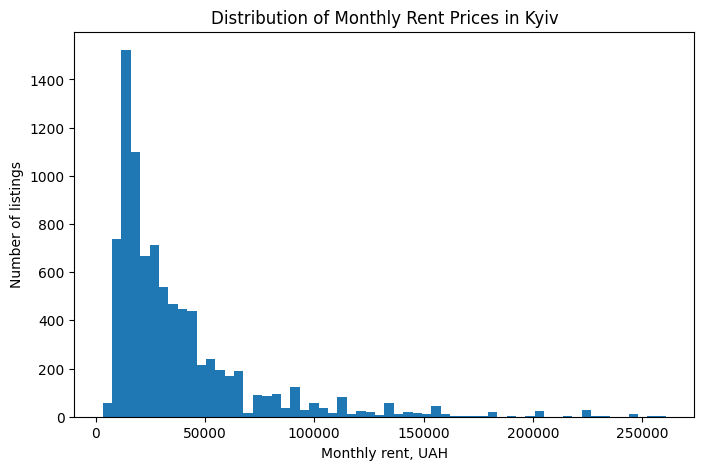

In [14]:
# Price distribution in UAH
plt.figure(figsize=(8, 5))
plt.hist(df["price_uah"], bins=60)
plt.title("Distribution of Monthly Rent Prices in Kyiv")
plt.xlabel("Monthly rent, UAH")
plt.ylabel("Number of listings")
plt.show()

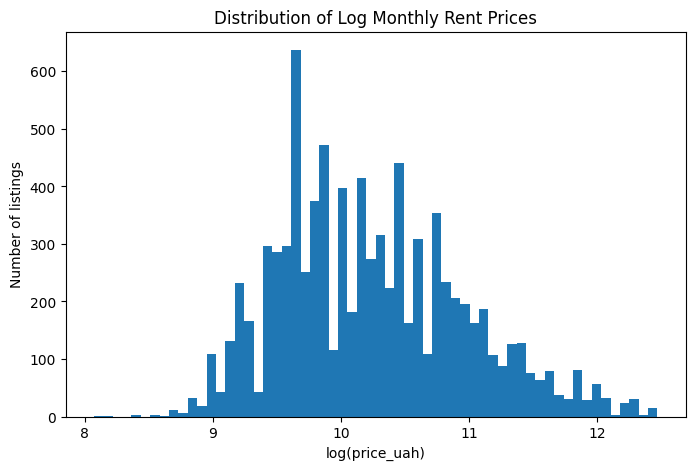

In [15]:
# Log price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=60)
plt.title("Distribution of Log Monthly Rent Prices")
plt.xlabel("log(price_uah)")
plt.ylabel("Number of listings")
plt.show()

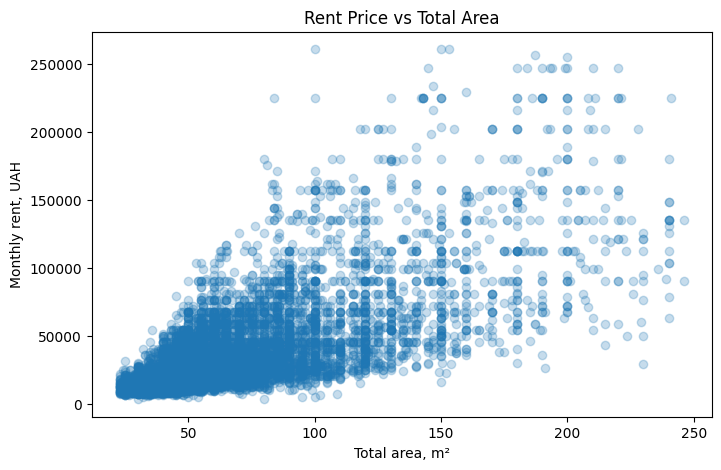

In [16]:
# Relationship between area and price
plt.figure(figsize=(8, 5))
plt.scatter(df["area_total"], df["price_uah"], alpha=0.25)
plt.title("Rent Price vs Total Area")
plt.xlabel("Total area, m²")
plt.ylabel("Monthly rent, UAH")
plt.show()

In [17]:
# Average rent by district
avg_by_district = (
    df.groupby("district", dropna=False)["price_uah"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

avg_by_district.head(15)

,count,mean,median
district,,,
Голосіївський,57,"52,820.96","54,000.00"
Печерський,927,"58,756.80","48,950.00"
Шевченківський,584,"46,047.76","38,250.00"
Подільський,315,"30,891.47","25,000.00"
NaN,5327,"37,292.02","25,000.00"
Оболонський,366,"26,625.03","19,982.50"
Святошинський,326,"18,376.69","16,250.00"
Дніпровський,796,"20,998.34","15,000.00"
Дарницький,2,"13,999.50","13,999.50"


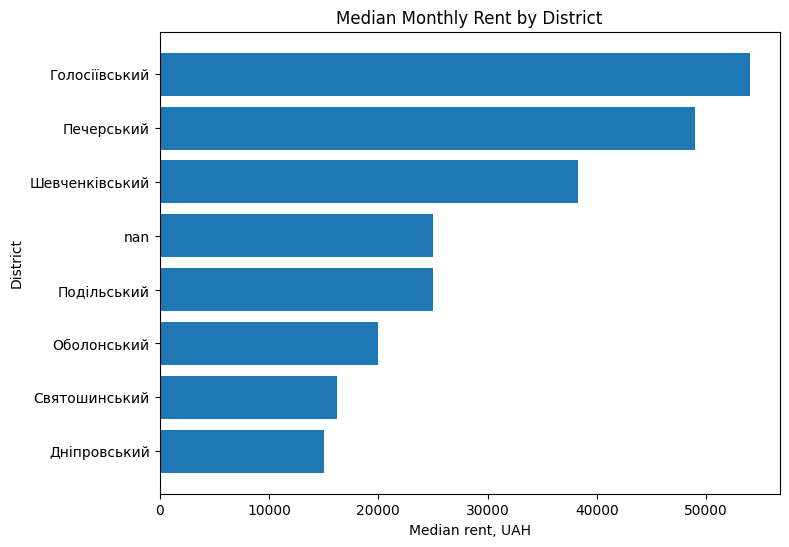

In [18]:
# Visualize districts with enough observations
plot_districts = avg_by_district[avg_by_district["count"] >= 50].sort_values("median")

plt.figure(figsize=(8, 6))
plt.barh(plot_districts.index.astype(str), plot_districts["median"])
plt.title("Median Monthly Rent by District")
plt.xlabel("Median rent, UAH")
plt.ylabel("District")
plt.show()

In [19]:
# Price by number of rooms
rooms_summary = df.groupby("rooms")["price_uah"].agg(["count", "mean", "median"]).sort_index()
rooms_summary

,count,mean,median
rooms,,,
1.00,3441,"21,865.27","18,000.00"
2.00,2989,"34,232.97","27,900.00"
3.00,1797,"55,788.94","45,000.00"
4.00,398,"97,202.34","84,375.00"
5.00,72,"116,491.67","107,850.00"
6.00,3,"115,500.00","63,000.00"


/var/folders/nk/7z1ywx_15gq_crc3996dd4vm0000gn/T/ipykernel_9717/2854142308.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


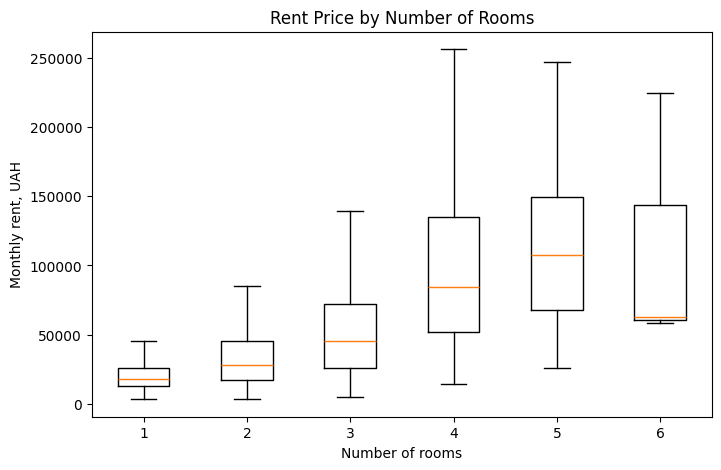

In [20]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df.loc[df["rooms"] == r, "price_uah"] for r in sorted(df["rooms"].dropna().unique())],
    labels=[str(int(r)) for r in sorted(df["rooms"].dropna().unique())],
    showfliers=False
)
plt.title("Rent Price by Number of Rooms")
plt.xlabel("Number of rooms")
plt.ylabel("Monthly rent, UAH")
plt.show()

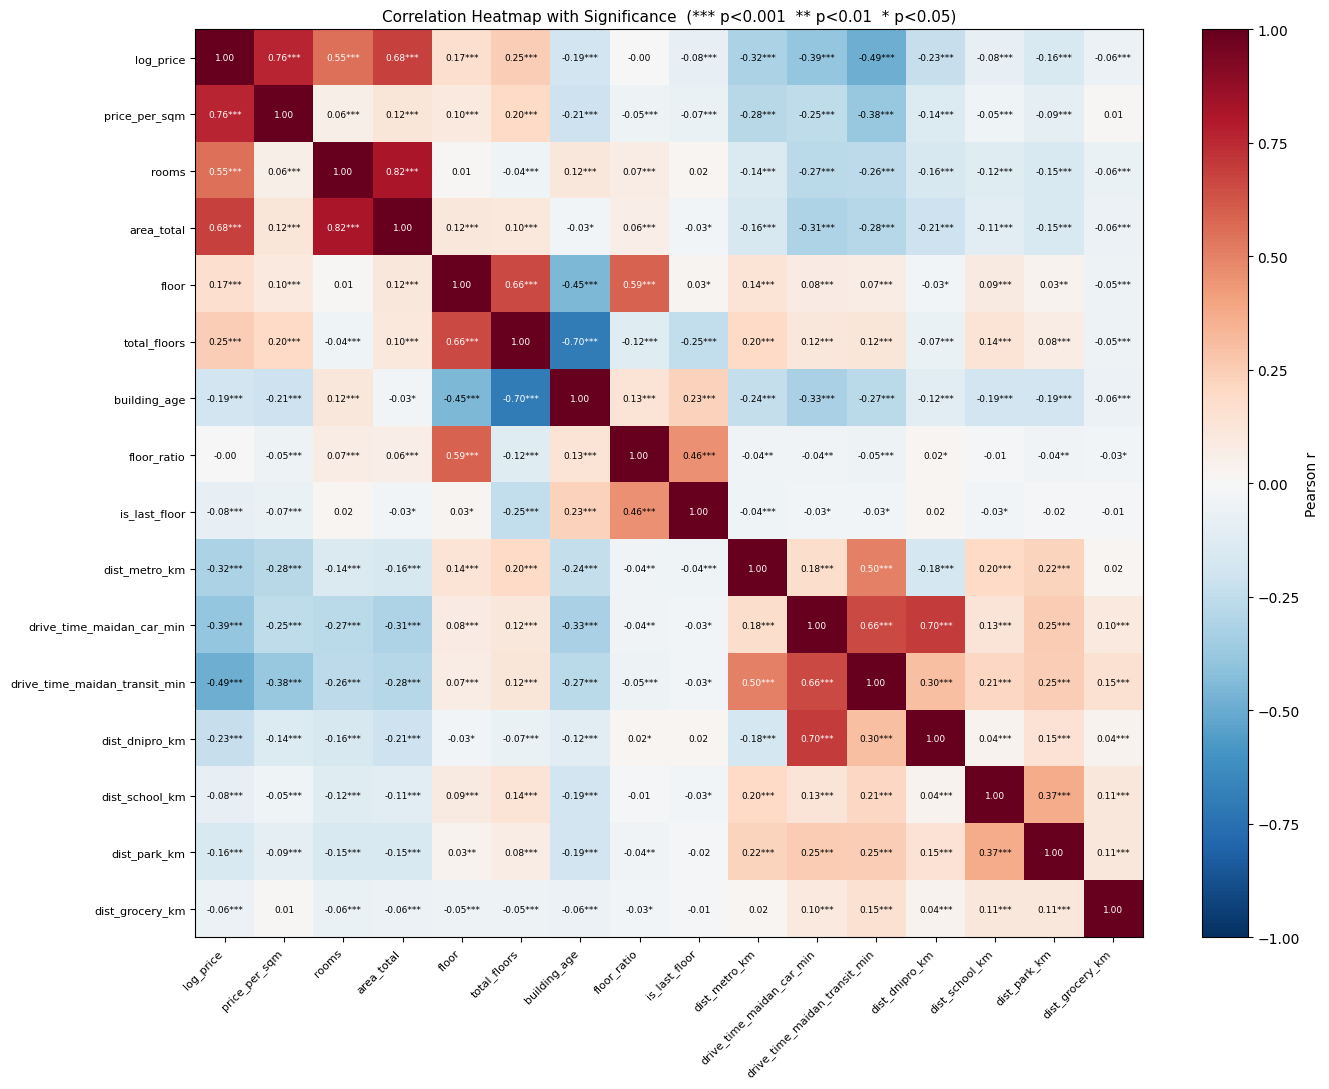

In [21]:
# Correlation heatmap with statistical significance (Pearson r + p-values)
numeric_heatmap_cols = [
    "log_price", "price_per_sqm",
    "rooms", "area_total", "floor", "total_floors", "building_age", "floor_ratio", "is_last_floor",
    "dist_metro_km", "drive_time_maidan_car_min", 'drive_time_maidan_transit_min', "dist_dnipro_km",
    "dist_school_km", "dist_park_km", 'dist_grocery_km', 
]
heatmap_data = df[numeric_heatmap_cols].dropna()
n = len(numeric_heatmap_cols)

corr_matrix = heatmap_data.corr().values
p_matrix = np.ones((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            _, p_matrix[i, j] = stats.pearsonr(heatmap_data.iloc[:, i], heatmap_data.iloc[:, j])

def significance_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")

for i in range(n):
    for j in range(n):
        r = corr_matrix[i, j]
        stars = significance_stars(p_matrix[i, j])
        color = "white" if abs(r) > 0.5 else "black"
        ax.text(j, i, f"{r:.2f}{stars}", ha="center", va="center", fontsize=6.5, color=color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(numeric_heatmap_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(numeric_heatmap_cols, fontsize=8)
ax.set_title("Correlation Heatmap with Significance  (*** p<0.001  ** p<0.01  * p<0.05)", fontsize=11)
plt.tight_layout()
plt.show()

### Geospatial Feature Analysis

The enriched dataset adds 10 geospatial features derived from coordinates: metro proximity, drive/transit times to Maidan, distances to bus stops, grocery stores, supermarket chains, schools, and parks, river-bank classification, and distance to the Dnipro river. We analyse their distributions and relationship with rent price below.

In [22]:
# Missing value counts for all geo features
geo_cols = [
    "dist_metro_km", "drive_time_maidan_car_min", "drive_time_maidan_transit_min",
    "dist_bus_stop_km", "bank_side", "dist_dnipro_km",
    "dist_grocery_km", "dist_supermarket_km", "dist_school_km", "dist_park_km"
]
existing_geo = [c for c in geo_cols if c in df.columns]

geo_missing = df[existing_geo].isna().sum().rename("missing")
geo_pct = (geo_missing / len(df) * 100).rename("pct_missing")
print(pd.concat([geo_missing, geo_pct.round(1)], axis=1).to_string())

                               missing  pct_missing
dist_metro_km                        0         0.00
drive_time_maidan_car_min            0         0.00
drive_time_maidan_transit_min        0         0.00
dist_bus_stop_km                     0         0.00
bank_side                            0         0.00
dist_dnipro_km                       0         0.00
dist_grocery_km                      0         0.00
dist_supermarket_km                  0         0.00
dist_school_km                       0         0.00
dist_park_km                         0         0.00


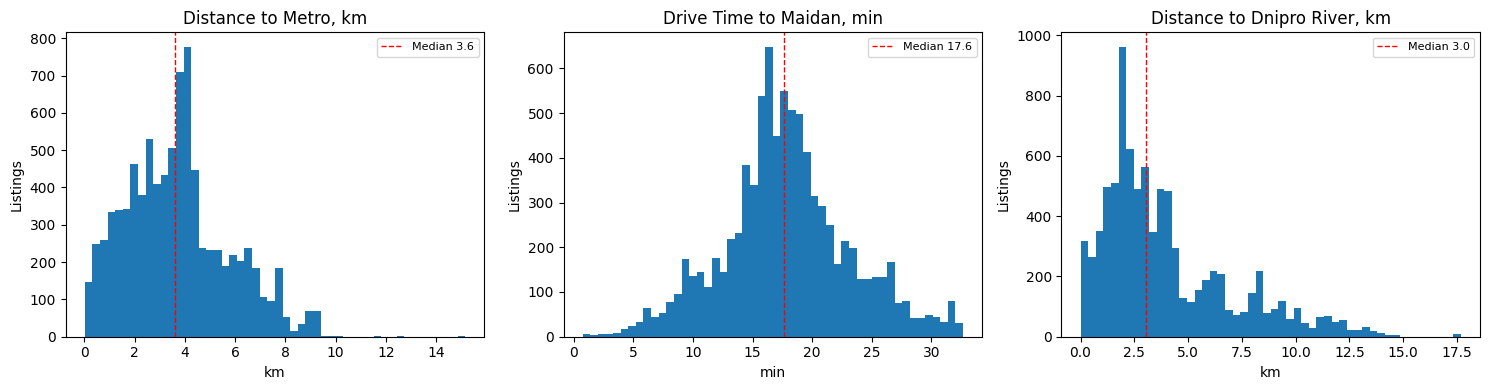

In [23]:
# Distributions of key distance and time features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(
    axes,
    ["dist_metro_km", "drive_time_maidan_car_min", "dist_dnipro_km"],
    ["Distance to Metro, km", "Drive Time to Maidan, min", "Distance to Dnipro River, km"]
):
    data = df[col].dropna()
    ax.hist(data, bins=50)
    ax.set_title(label)
    ax.set_xlabel(label.split(",")[1].strip() if "," in label else "")
    ax.set_ylabel("Listings")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1, label=f"Median {data.median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/nk/7z1ywx_15gq_crc3996dd4vm0000gn/T/ipykernel_9717/445919247.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


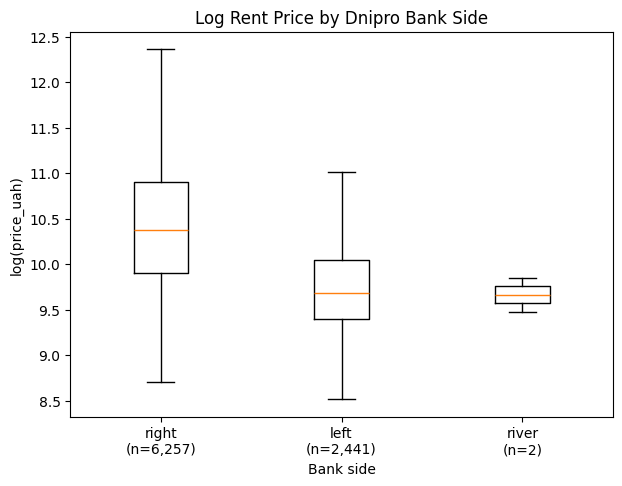

Median log price by bank side:
bank_side
left     9.68
right   10.37
river    9.66
Name: log_price, dtype: float64


In [24]:
# Log rent price by Dnipro bank side
bank_order = ["right", "left", "river"]
valid = df.dropna(subset=["bank_side", "log_price"])

bank_data = [valid.loc[valid["bank_side"] == b, "log_price"] for b in bank_order]
bank_labels = [f"{b}\n(n={len(d):,})" for b, d in zip(bank_order, bank_data)]
bank_data_nonempty = [(d, l) for d, l in zip(bank_data, bank_labels) if len(d) > 0]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [d for d, _ in bank_data_nonempty],
    labels=[l for _, l in bank_data_nonempty],
    showfliers=False
)
plt.title("Log Rent Price by Dnipro Bank Side")
plt.ylabel("log(price_uah)")
plt.xlabel("Bank side")
plt.show()

print("Median log price by bank side:")
print(valid.groupby("bank_side")["log_price"].median().round(3))

In [25]:
list(df['currency'].unique())

['UAH', 'USD', 'EUR']

/var/folders/nk/7z1ywx_15gq_crc3996dd4vm0000gn/T/ipykernel_9717/3179826477.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


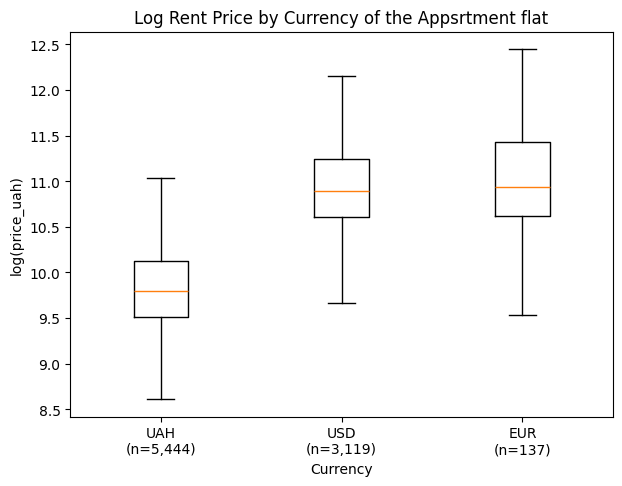

Median log price by currency:
currency
EUR   10.94
UAH    9.80
USD   10.90
Name: log_price, dtype: float64


In [26]:
# Log rent price by currency in data
currency_diff = list(df['currency'].unique())
valid = df.dropna(subset=["currency", "log_price"])

curr_data = [valid.loc[valid["currency"] == b, "log_price"] for b in currency_diff]
curr_labels = [f"{b}\n(n={len(d):,})" for b, d in zip(currency_diff, curr_data)]
curr_data_nonempty = [(d, l) for d, l in zip(curr_data, curr_labels) if len(d) > 0]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [d for d, _ in curr_data_nonempty],
    labels=[l for _, l in curr_data_nonempty],
    showfliers=False
)
plt.title("Log Rent Price by Currency of the Appsrtment flat")
plt.ylabel("log(price_uah)")
plt.xlabel("Currency")
plt.show()

print("Median log price by currency:")
print(valid.groupby("currency")["log_price"].median().round(3))

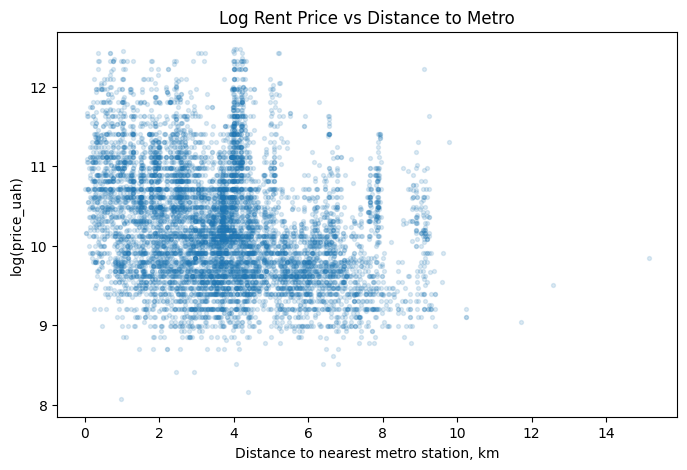

Pearson correlation (dist_metro_km vs log_price): -0.304


In [27]:
# Log rent price vs distance to metro
scatter_data = df.dropna(subset=["dist_metro_km", "log_price"])

plt.figure(figsize=(8, 5))
plt.scatter(scatter_data["dist_metro_km"], scatter_data["log_price"], alpha=0.15, s=8)
plt.title("Log Rent Price vs Distance to Metro")
plt.xlabel("Distance to nearest metro station, km")
plt.ylabel("log(price_uah)")
plt.show()

corr = scatter_data[["dist_metro_km", "log_price"]].corr().iloc[0, 1]
print(f"Pearson correlation (dist_metro_km vs log_price): {corr:.3f}")

### Feature Correlations with Log Price

Each scatter plot below shows a numeric feature against `log_price`. The Pearson r and significance level are shown in each title. Stars: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant.

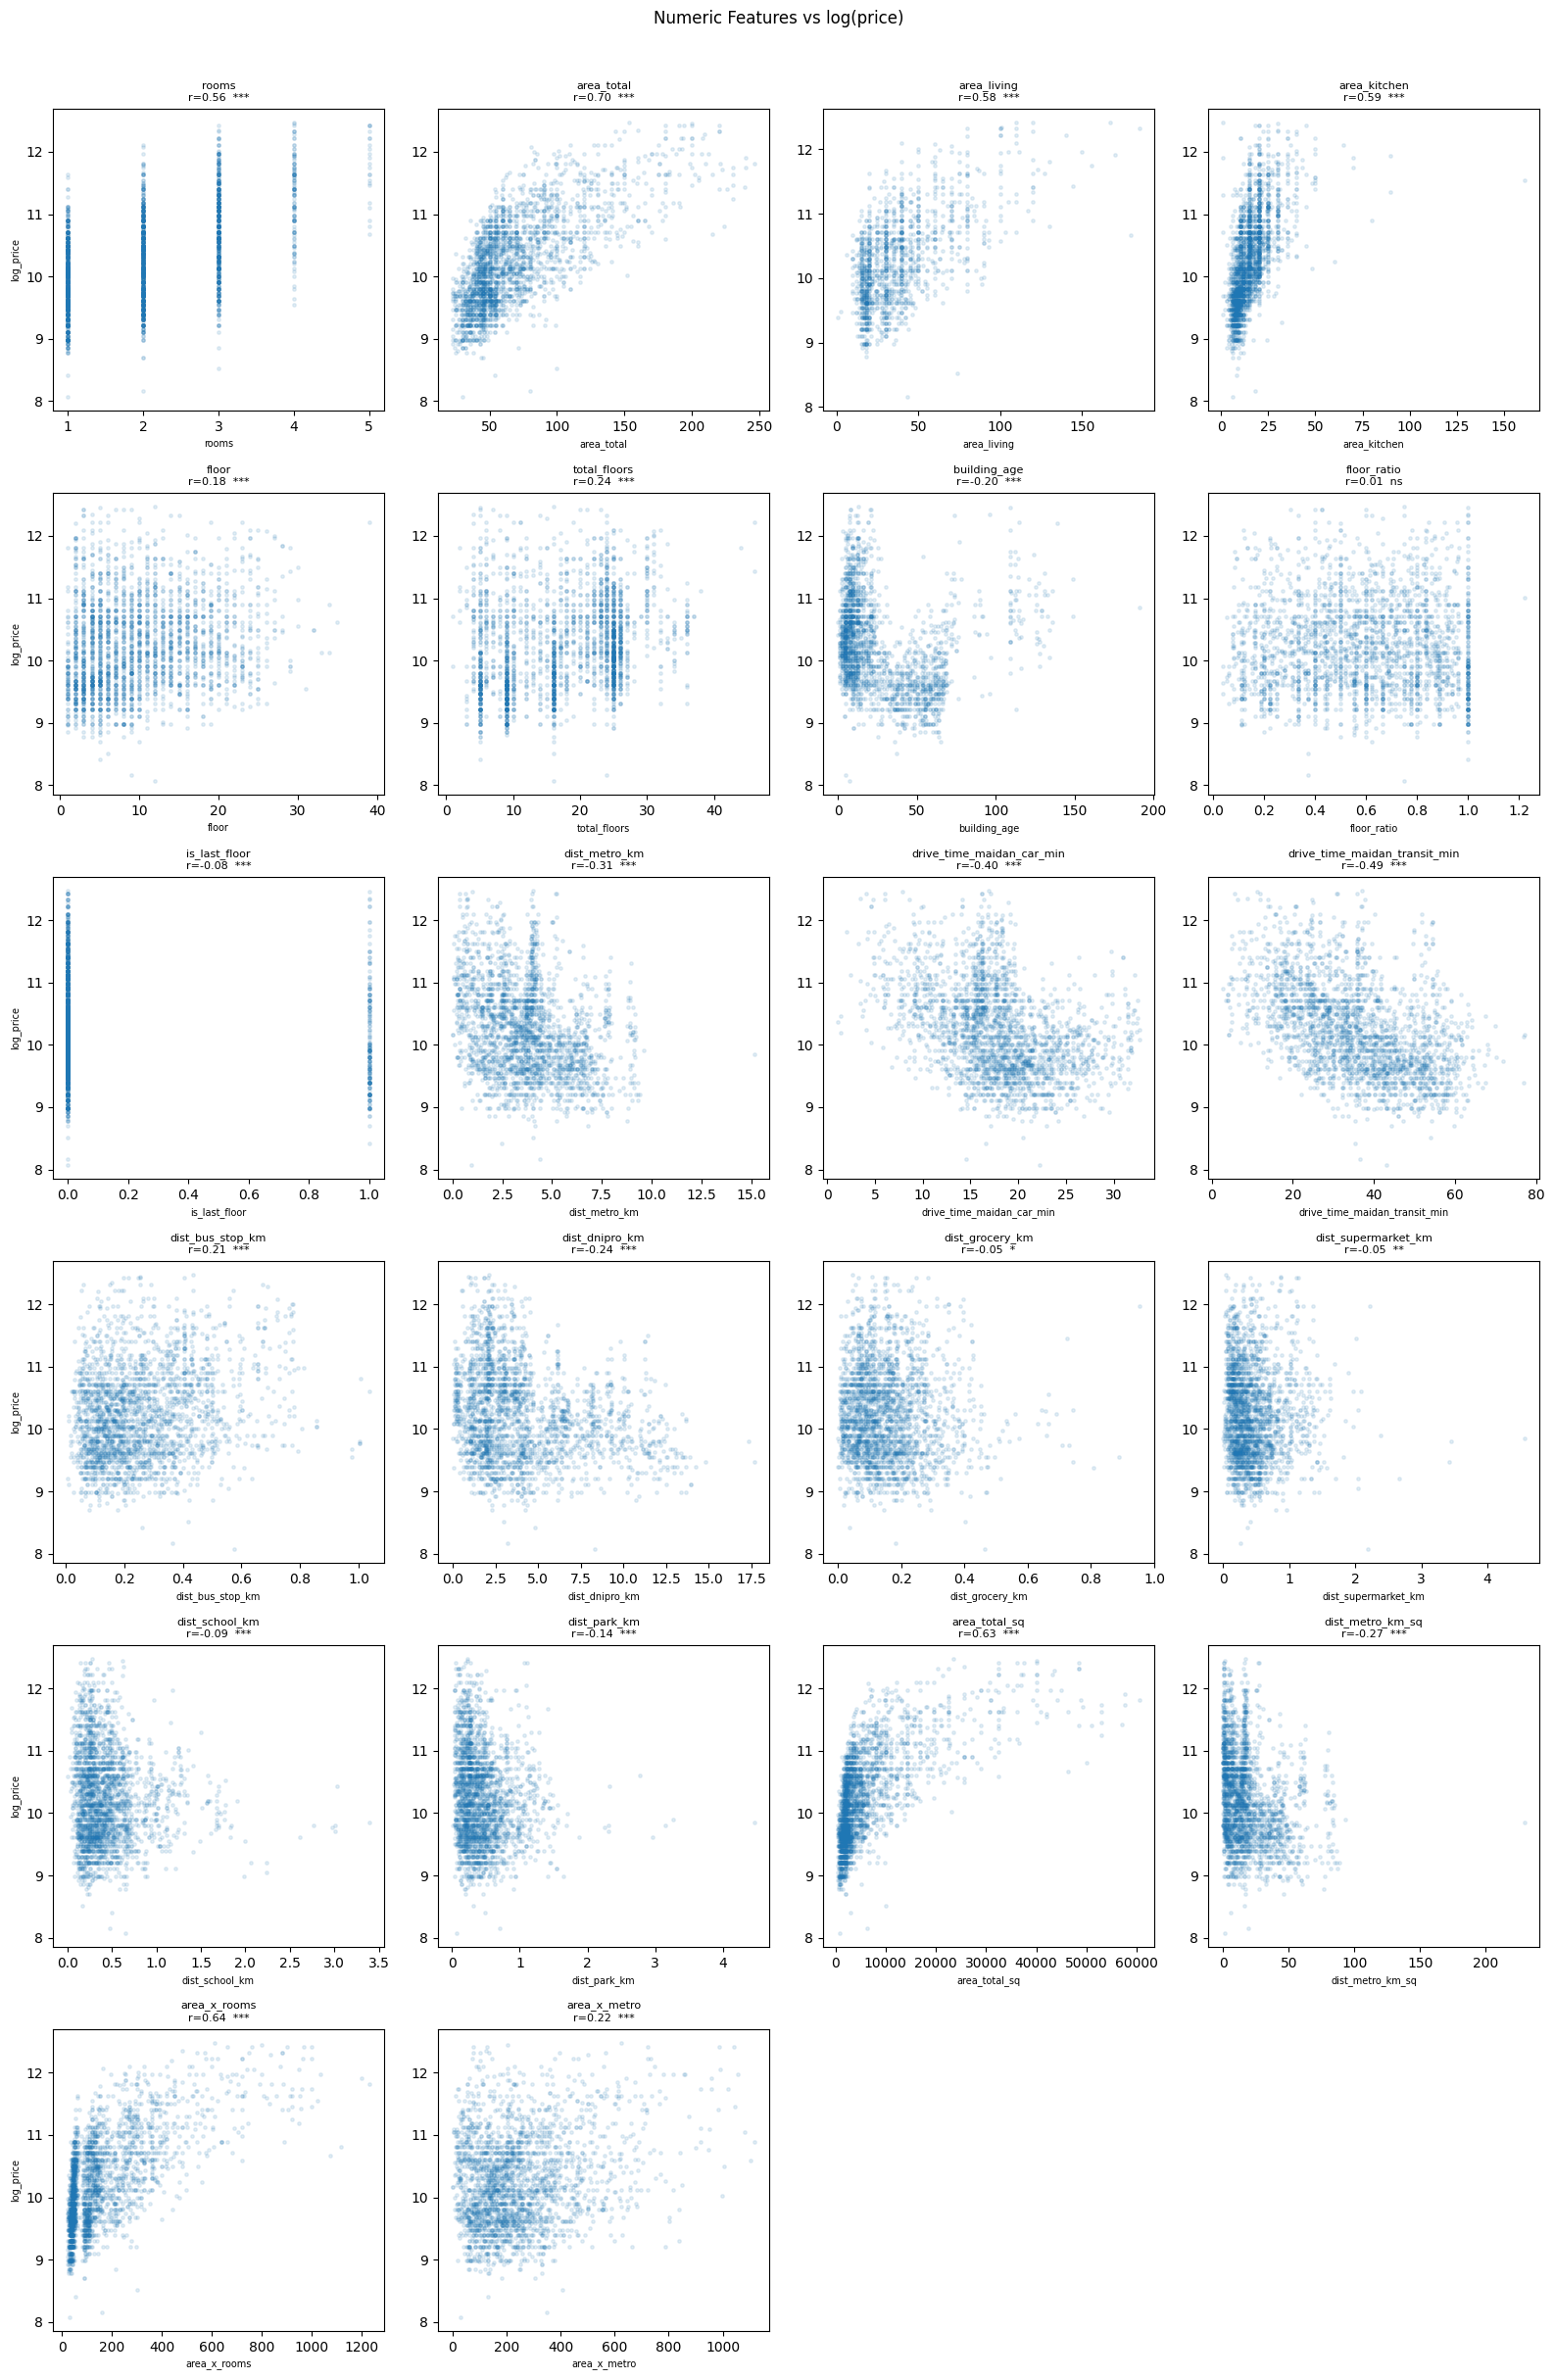

In [28]:
scatter_numeric_cols = [
    "rooms", "area_total", "area_living", "area_kitchen",
    "floor", "total_floors", "building_age", "floor_ratio", "is_last_floor",
    "dist_metro_km", "drive_time_maidan_car_min", "drive_time_maidan_transit_min",
    "dist_bus_stop_km", "dist_dnipro_km", "dist_grocery_km", "dist_supermarket_km",
    "dist_school_km", "dist_park_km",
    "area_total_sq", "dist_metro_km_sq", "area_x_rooms", "area_x_metro",
]

sample = df[scatter_numeric_cols + ["log_price"]].dropna(subset=["log_price"]).sample(
    min(2500, len(df)), random_state=42
)

n_cols = 4
n_rows = (len(scatter_numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(scatter_numeric_cols):
    ax = axes[i]
    valid = sample[[col, "log_price"]].dropna()
    if len(valid) < 10:
        ax.set_visible(False)
        continue
    r, p = stats.pearsonr(valid[col], valid["log_price"])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.scatter(valid[col], valid["log_price"], alpha=0.12, s=6)
    ax.set_title(f"{col}\nr={r:.2f}  {sig}", fontsize=8)
    ax.set_xlabel(col, fontsize=7)
    if i % n_cols == 0:
        ax.set_ylabel("log_price", fontsize=7)

for i in range(len(scatter_numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Numeric Features vs log(price)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### EDA interpretation

The rent-price distribution is right-skewed: most listings have moderate prices, while a smaller number of premium apartments are much more expensive. This is why `log_price` is used as the modeling target. Larger apartments and apartments in more central or expensive districts tend to have higher rents.

Geospatial features reveal additional patterns: apartments closer to metro stations tend to command higher prices, and right-bank (western) apartments generally rent for more than left-bank ones — reflecting the greater concentration of business districts and older urban fabric on the right bank. Drive time to Maidan (the central reference point) also correlates negatively with price.

Location, area, number of rooms, and metro proximity are expected to be among the most important predictors.

## 5. Model Preparation

We use the following predictors. Numeric variables are imputed with the median and standardized. Categorical variables are imputed with the most frequent category and one-hot encoded.

The train-test split is 80/20. The models are trained on `log_price`, while final metrics are reported both on the log scale and after converting predictions back to UAH.

In [29]:
features = [
    # Apartment characteristics
    "rooms", "area_total", "area_living", "area_kitchen",
    "floor", "total_floors", "building_age", "floor_ratio", "is_last_floor",
    # Building attributes
    "construction_tech", "heating_type",
    # Administrative
    "has_commission",
    # Geospatial engineered features (no raw lat/lon — uninterpretable)
    "dist_metro_km",
    "drive_time_maidan_car_min", "drive_time_maidan_transit_min",
    "dist_bus_stop_km",
    "bank_side",
    "dist_dnipro_km",
    "dist_grocery_km", "dist_supermarket_km",
    "dist_school_km", "dist_park_km",
    # Polynomial / interaction terms
    "area_total_sq", "rooms_sq", "dist_metro_km_sq",
    "drive_time_maidan_car_min_sq", "building_age_sq",
    "area_x_rooms", "area_x_metro", "area_x_drive", "rooms_x_metro",
]

target = "log_price"

model_data = df[features + ["price_uah", target]].copy()

X = model_data[features]
y = model_data[target]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Modeling data shape:", model_data.shape)

Numeric features: ['rooms', 'area_total', 'area_living', 'area_kitchen', 'floor', 'total_floors', 'building_age', 'floor_ratio', 'is_last_floor', 'has_commission', 'dist_metro_km', 'drive_time_maidan_car_min', 'drive_time_maidan_transit_min', 'dist_bus_stop_km', 'dist_dnipro_km', 'dist_grocery_km', 'dist_supermarket_km', 'dist_school_km', 'dist_park_km', 'area_total_sq', 'rooms_sq', 'dist_metro_km_sq', 'drive_time_maidan_car_min_sq', 'building_age_sq', 'area_x_rooms', 'area_x_metro', 'area_x_drive', 'rooms_x_metro']
Categorical features: ['construction_tech', 'heating_type', 'bank_side']
Modeling data shape: (8700, 33)


In [30]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8700 entries, 4 to 10361
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   rooms                          8700 non-null   float64
 1   area_total                     8700 non-null   float64
 2   area_living                    4803 non-null   float64
 3   area_kitchen                   8645 non-null   float64
 4   floor                          8700 non-null   float64
 5   total_floors                   8700 non-null   float64
 6   building_age                   7586 non-null   float64
 7   floor_ratio                    8697 non-null   float64
 8   is_last_floor                  8700 non-null   int64  
 9   construction_tech              8195 non-null   object 
 10  heating_type                   8182 non-null   object 
 11  has_commission                 8700 non-null   int64  
 12  dist_metro_km                  8700 non-null   float

In [31]:
numeric_transformer = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (6960, 31)
Test set: (1740, 31)


## 6. Model Development

We estimate four models:

1. **Linear Regression** — simple interpretable baseline.
2. **Ridge Regression** — linear model with L2 regularization.
3. **Random Forest** — advanced nonlinear model based on many decision trees.
4. **Gradient Boosting** — advanced nonlinear ensemble model.

This allows us to compare interpretability and predictive accuracy.

In [33]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge Regression": RidgeCV(alphas=[0.1, 1, 10, 50, 100]),

#     "RF_Shallow": RandomForestRegressor(
#         n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
#     ),
#     "RF_Deep": RandomForestRegressor(
#         n_estimators=150, max_depth=25, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1
#     ),
#     "RF_Many_Trees": RandomForestRegressor(
#         n_estimators=300, max_depth=15, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
#     ),
#     "RF_Regularized": RandomForestRegressor(
#         n_estimators=150, max_depth=18, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1
#     ),
#     "RF_Balanced": RandomForestRegressor(
#         n_estimators=200, max_depth=18, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
#     ),

#     "GB_Fast": GradientBoostingRegressor(
#         n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
#     ),
#     "GB_Slow_Deep": GradientBoostingRegressor(
#         n_estimators=500, learning_rate=0.01, max_depth=8, random_state=RANDOM_STATE
#     ),
#     "GB_Subsampled": GradientBoostingRegressor(
#         n_estimators=250, learning_rate=0.05, max_depth=6,
#         subsample=0.7, max_features=0.8, random_state=RANDOM_STATE
#     ),
#     "GB_Regularized": GradientBoostingRegressor(
#         n_estimators=200, learning_rate=0.05, max_depth=5,
#         min_samples_leaf=10, min_samples_split=15, random_state=RANDOM_STATE
#     ),
#     "GB_Balanced": GradientBoostingRegressor(
#         n_estimators=300, learning_rate=0.03, max_depth=6, random_state=RANDOM_STATE
#     ),
# }

# if XGBOOST_AVAILABLE:
#     models["XGBoost"] = XGBRegressor(
#         n_estimators=300, learning_rate=0.05, max_depth=5,
#         subsample=0.8, colsample_bytree=0.8,
#         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
#     )



models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": RidgeCV(alphas=[0.1, 1, 10, 50, 100]),

    "RF_Best_Base": RandomForestRegressor(
        n_estimators=150, max_depth=25, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "RF_Var1_More_Trees_Reg": RandomForestRegressor( 
        n_estimators=300, max_depth=30, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "GB_Var1_Slow": GradientBoostingRegressor( 
        n_estimators=400, learning_rate=0.03, max_depth=6,
        subsample=0.75, max_features=0.8, random_state=RANDOM_STATE
    ),
}

if XGBOOST_AVAILABLE:
    models["XGB_Var1_Slow_Deep"] = XGBRegressor( 
        n_estimators=400, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

In [34]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Fit model and compute metrics on train and test data."""
    pipeline.fit(X_train, y_train)
    
    train_pred_log = pipeline.predict(X_train)
    test_pred_log = pipeline.predict(X_test)
    
    # Convert log predictions back to UAH for practical interpretation
    train_pred_uah = np.exp(train_pred_log)
    test_pred_uah = np.exp(test_pred_log)
    train_true_uah = np.exp(y_train)
    test_true_uah = np.exp(y_test)
    
    return {
        "Model": name,
        "Train RMSE (UAH)": np.sqrt(mean_squared_error(train_true_uah, train_pred_uah)),
        "Test RMSE (UAH)": np.sqrt(mean_squared_error(test_true_uah, test_pred_uah)),
        "Train MAE (UAH)": mean_absolute_error(train_true_uah, train_pred_uah),
        "Test MAE (UAH)": mean_absolute_error(test_true_uah, test_pred_uah),
        "Train R2 (log)": r2_score(y_train, train_pred_log),
        "Test R2 (log)": r2_score(y_test, test_pred_log),
        "pipeline": pipeline
    }

In [35]:
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    output = evaluate_model(name, pipe, X_train, X_test, y_train, y_test)
    fitted_pipelines[name] = output.pop("pipeline")
    results.append(output)

results_df = pd.DataFrame(results).sort_values("Test RMSE (UAH)")
results_df

,Model,Train RMSE (UAH),Test RMSE (UAH),Train MAE (UAH),Test MAE (UAH),Train R2 (log),Test R2 (log)
4,GB_Var1_Slow,"8,323.78","15,473.13","4,835.63","7,982.90",0.95,0.88
5,XGB_Var1_Slow_Deep,"8,697.32","15,897.86","4,869.22","8,175.46",0.95,0.87
2,RF_Best_Base,"6,760.73","16,627.21","3,221.39","8,644.63",0.98,0.86
3,RF_Var1_More_Trees_Reg,"8,007.00","16,812.59","3,685.07","8,686.98",0.97,0.86
0,Linear Regression,"20,888.85","21,302.17","10,921.12","11,256.42",0.79,0.79
1,Ridge Regression,"20,919.21","21,306.44","10,927.16","11,249.35",0.79,0.79


## 7. Cross-Validation

To obtain a more stable estimate of predictive performance, we also run 5-fold cross-validation on the training set. The scoring is based on RMSE of log prices. Lower values are better.

In [36]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    neg_mse_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    
    rmse_scores = np.sqrt(-neg_mse_scores)
    cv_results.append({
        "Model": name,
        "CV RMSE log mean": rmse_scores.mean(),
        "CV RMSE log std": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE log mean")
cv_results_df

,Model,CV RMSE log mean,CV RMSE log std
5,XGB_Var1_Slow_Deep,0.27,0.01
4,GB_Var1_Slow,0.27,0.01
2,RF_Best_Base,0.28,0.01
3,RF_Var1_More_Trees_Reg,0.28,0.01
1,Ridge Regression,0.34,0.01
0,Linear Regression,0.34,0.01


## 8. Model Interpretation

For the linear model, coefficients are directly interpretable after preprocessing, but one-hot encoding makes the full coefficient table long. For the advanced models, we use permutation importance. It measures how much model performance worsens when each variable is randomly shuffled. If shuffling a variable strongly worsens performance, that variable is important.

In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print("Best model based on test RMSE:", best_model_name)

Best model based on test RMSE: GB_Var1_Slow


In [38]:
# Permutation importance for the best model
# We use the original columns before preprocessing; this gives importance by original feature.
perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
22,area_total_sq,0.08,0.00
14,drive_time_maidan_transit_min,0.07,0.00
6,building_age,0.07,0.00
3,area_kitchen,0.06,0.00
16,bank_side,0.06,0.00
1,area_total,0.05,0.00
17,dist_dnipro_km,0.04,0.00
26,building_age_sq,0.02,0.00
27,area_x_rooms,0.02,0.00
15,dist_bus_stop_km,0.01,0.00


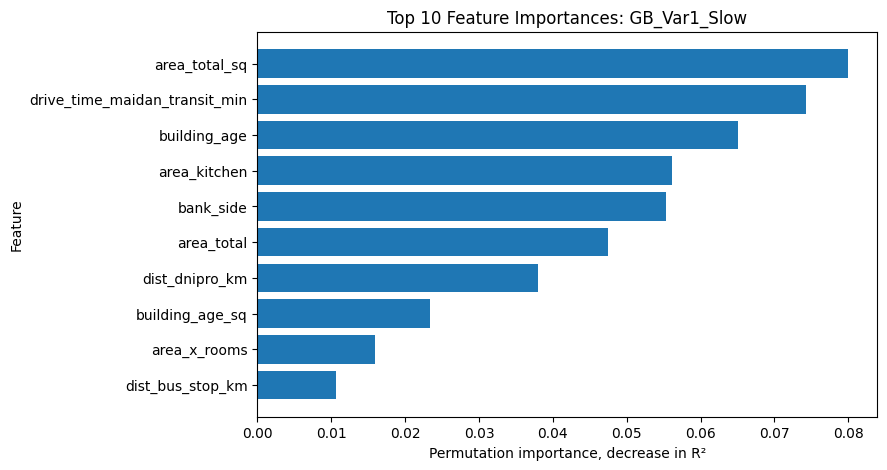

In [39]:
top_importance = importance_df.head(10).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title(f"Top 10 Feature Importances: {best_model_name}")
plt.xlabel("Permutation importance, decrease in R²")
plt.ylabel("Feature")
plt.show()

### SHAP Values

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, showing both the direction and magnitude of each feature's effect on the predicted price. The summary plot shows every test observation as a dot: its horizontal position is the SHAP value (impact on log_price), and colour indicates the original feature value (red = high, blue = low).

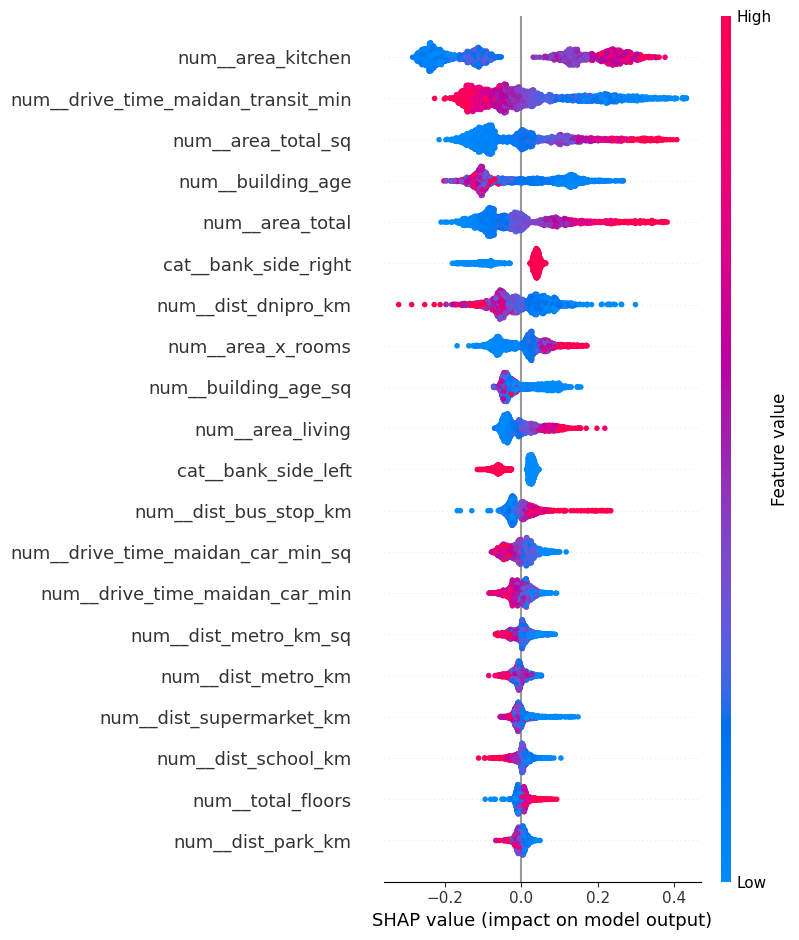

In [40]:
try:
    import shap

    shap_pipeline = fitted_pipelines[best_model_name]
    shap_model    = shap_pipeline.named_steps["model"]
    shap_prep     = shap_pipeline.named_steps["preprocess"]

    X_test_proc   = shap_prep.transform(X_test)
    feature_names = shap_prep.get_feature_names_out()

    explainer   = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_test_proc)

    shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names, max_display=20)

except ImportError:
    print("shap not installed. Run: pip install shap")

### Interpretation of model results

The best model is selected based on the lowest test RMSE. If Random Forest or Gradient Boosting performs better than Linear Regression, this suggests that Kyiv rent prices depend on nonlinear relationships and interactions between apartment characteristics. For example, the effect of area may differ by district or building type.

At the same time, Linear Regression and Ridge Regression remain useful as interpretable baselines. They provide a transparent benchmark and help us understand whether more complex models are actually needed.

## 9. Prediction Example

The next cell shows how to generate predictions for several test observations. This is useful for checking whether predicted prices are realistic.

In [41]:
example_predictions = X_test.copy().head(10)
example_true = np.exp(y_test.head(10))
example_pred = np.exp(best_pipeline.predict(example_predictions))

prediction_check = example_predictions.copy()
prediction_check["actual_price_uah"] = example_true.values
prediction_check["predicted_price_uah"] = example_pred
prediction_check["prediction_error_uah"] = prediction_check["predicted_price_uah"] - prediction_check["actual_price_uah"]

prediction_check[["actual_price_uah", "predicted_price_uah", "prediction_error_uah", "rooms", "area_total"]]

,actual_price_uah,predicted_price_uah,prediction_error_uah,rooms,area_total
3337,"10,000.00","13,623.31","3,623.31",1.00,42.00
3810,"13,000.00","18,468.92","5,468.92",2.00,97.00
10286,"14,990.00","19,056.60","4,066.60",1.00,47.00
5490,"14,500.00","15,091.94",591.94,1.00,38.00
4900,"9,500.00","10,576.11","1,076.11",1.00,28.70
7766,"47,250.00","30,127.68","-17,122.32",1.00,50.40
7039,"67,500.00","87,505.63","20,005.63",4.00,151.00
7018,"13,500.00","14,632.63","1,132.63",1.00,36.00
3763,"71,400.00","94,788.29","23,388.29",3.00,140.00
2233,"22,000.00","19,012.55","-2,987.45",1.00,72.00


## 10. Discussion and Limitations

Main limitations:

1. **Exchange-rate assumption:** USD and EUR listings were converted to UAH using fixed approximate rates. More precise work should use official exchange rates for the scraping date.
2. **Listing prices are asking prices:** The dataset reflects advertised rents, not necessarily final transaction prices.
3. **Missing values:** Some variables have many missing observations, especially commission, building year, and district. Approximately 337 listings have no GPS coordinates and therefore have missing values for all geospatial features — these are imputed with medians or most-frequent values during modelling.
4. **Geospatial feature coverage:** Drive times (Google Distance Matrix API) and OSM-based proximity features are available only for the ~10,025 listings that had valid coordinates. Transit times may have additional missing values where the API returned no result.
5. **Text information is mostly unused:** Descriptions may contain important information such as renovation quality, pets allowed, parking, appliances, blackout autonomy, and metro proximity. This could be captured through NLP feature engineering.
6. **Potential duplicates or repeated listings:** Even after removing duplicate URLs, very similar listings may remain.

These limitations should be mentioned in the final presentation and report.

## 11. Conclusions

This project applies supervised machine learning to predict monthly apartment rental prices in Kyiv. The target variable is log monthly rent in UAH. The models use apartment characteristics, location, and building information.

The project compares interpretable linear models with more flexible machine learning models. The final model should be chosen based on test performance and practical interpretability. In most real-estate datasets, ensemble tree-based models such as Random Forest or Gradient Boosting are expected to perform better because they capture nonlinear relationships and interactions.

The most important practical factors are expected to include apartment area, district/location, number of rooms, floor characteristics, and building-related variables.

## 13. Unsupervised Learning: Rental Market Segmentation

Supervised models tell us how well observable features predict rent — but they don't reveal whether the Kyiv rental market has *natural segments*. Unsupervised learning answers: **Do Kyiv apartments cluster into distinct tiers?**

We apply three complementary methods required by the course:
1. **K-Means Clustering** — partitions listings into k groups by minimising within-cluster variance. Fast, scalable, assumes spherical clusters.
2. **Agglomerative (Hierarchical) Clustering** — builds a dendrogram using Ward linkage and cuts it at the chosen depth. Does not assume spherical clusters; useful for detecting elongated or nested structures.
3. **PCA (Principal Component Analysis)** — projects the high-dimensional feature space onto 2 axes that capture maximum variance, enabling visual inspection of cluster geometry and price gradients.

The number of clusters k is selected objectively via the **elbow method** (inertia) and **silhouette score**. Clusters are profiled by median price and key features, and the two clustering methods are compared with the **Adjusted Rand Index (ARI)**.

In [ ]:
# 13.1 — Data preparation for clustering
# Use only numeric features (same set as the supervised pipeline, minus categoricals).
# Apply median imputation so missing values don't distort distances,
# then StandardScaler so all features contribute equally regardless of unit.

clust_numeric = numeric_features  # defined in Section 5

clust_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

X_clust_raw = df[clust_numeric].copy()
X_clust     = clust_prep.fit_transform(X_clust_raw)

print(f"Clustering matrix shape:  {X_clust.shape}")
print(f"Number of features used:  {len(clust_numeric)}")
print(f"Missing values after imputation: {np.isnan(X_clust).sum()}")

In [ ]:
# 13.2 — Choosing the number of clusters: Elbow method + Silhouette score
K_RANGE = range(2, 11)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_clust, labels, sample_size=2000, random_state=RANDOM_STATE)
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, marker="o")
axes[0].set_title("Elbow Method — Within-Cluster Inertia")
axes[0].set_xlabel("Number of clusters  k")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Silhouette Score  (higher = better separation)")
axes[1].set_xlabel("Number of clusters  k")
axes[1].set_ylabel("Average silhouette")
axes[1].set_xticks(list(K_RANGE))

plt.suptitle("Selecting the Number of Clusters", fontsize=12)
plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    print(f"  k={k:2d}:  {s:.4f}")

In [ ]:
# 13.3 — K-Means with the optimal k
k_opt = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f"Optimal k by silhouette score: {k_opt}")

km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(X_clust)

# Cluster profile: key metrics per cluster, sorted by median rent
cluster_profile = (
    df.groupby("cluster_kmeans")
    .agg(
        count          = ("price_uah",              "count"),
        median_rent    = ("price_uah",              "median"),
        median_area_m2 = ("area_total",             "median"),
        median_rooms   = ("rooms",                  "median"),
        median_metro_km= ("dist_metro_km",          "median"),
        median_min_maidan=("drive_time_maidan_car_min","median"),
        median_age     = ("building_age",           "median"),
        dominant_bank  = ("bank_side", lambda x: x.mode()[0]),
    )
    .sort_values("median_rent")
)
print("\nCluster profile (sorted by median monthly rent):")
print(cluster_profile.to_string())

# Bar chart: median rent per cluster
plt.figure(figsize=(7, 4))
colors = [plt.cm.tab10.colors[i] for i in range(len(cluster_profile))]
bars = plt.bar(cluster_profile.index.astype(str),
               cluster_profile["median_rent"] / 1_000,
               color=colors)
plt.title(f"K-Means (k={k_opt}): Median Monthly Rent per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Median rent, thousands UAH")
for bar, val in zip(bars, cluster_profile["median_rent"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             f"{val/1000:.0f}k", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 13.4 — PCA 2D visualisation of the apartment feature space
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)

print(f"PCA explained variance:  PC1 = {pca.explained_variance_ratio_[0]:.1%},  "
      f"PC2 = {pca.explained_variance_ratio_[1]:.1%},  "
      f"combined = {sum(pca.explained_variance_ratio_):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coloured by K-Means cluster label
s1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["cluster_kmeans"], cmap="tab10", alpha=0.3, s=6)
axes[0].set_title(f"PCA — coloured by K-Means cluster  (k={k_opt})")
axes[0].set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(s1, ax=axes[0], label="Cluster")

# Right: coloured by log(monthly rent) — shows whether clusters align with price
s2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["log_price"], cmap="RdYlGn", alpha=0.3, s=6,
                      vmin=df["log_price"].quantile(0.05),
                      vmax=df["log_price"].quantile(0.95))
axes[1].set_title("PCA — coloured by log(monthly rent, UAH)")
axes[1].set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(s2, ax=axes[1], label="log(price_uah)")

plt.suptitle("PCA Projection of Apartment Feature Space", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 13.5 — Agglomerative (Hierarchical) Clustering with Ward linkage
agg = AgglomerativeClustering(n_clusters=k_opt, linkage="ward")
df["cluster_agg"] = agg.fit_predict(X_clust)

# Compare with K-Means using Adjusted Rand Index
ari = adjusted_rand_score(df["cluster_kmeans"], df["cluster_agg"])
print(f"Adjusted Rand Index (K-Means vs Agglomerative, Ward): {ari:.4f}")
print("  (ARI = 1.0 → identical assignments;  ARI ≈ 0 → chance-level agreement)")

# Agglomerative cluster profile
agg_profile = (
    df.groupby("cluster_agg")
    .agg(
        count=("price_uah", "count"),
        median_price_uah=("price_uah", "median"),
        median_area=("area_total", "median"),
        median_rooms=("rooms", "median"),
        median_dist_metro=("dist_metro_km", "median"),
        dominant_bank=("bank_side", lambda x: x.mode()[0]),
    )
    .sort_values("median_price_uah")
)
print("\nAgglomerative cluster profile (sorted by median rent):")
print(agg_profile.to_string())

# Side-by-side PCA scatter: K-Means vs Agglomerative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s_km = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster_kmeans"],
                        cmap="tab10", alpha=0.3, s=6)
axes[0].set_title(f"K-Means  (k={k_opt})")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(s_km, ax=axes[0], label="Cluster")

s_ag = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster_agg"],
                        cmap="tab10", alpha=0.3, s=6)
axes[1].set_title(f"Agglomerative / Ward  (k={k_opt})")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(s_ag, ax=axes[1], label="Cluster")

plt.suptitle(f"K-Means vs Agglomerative Clustering   ARI = {ari:.3f}", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 13.6 — Visual comparison of cluster profiles
# Boxplots of key continuous features + bank_side distribution per cluster

num_compare = [
    ("price_uah",                "Monthly rent, UAH"),
    ("area_total",               "Total area, m²"),
    ("rooms",                    "Rooms"),
    ("dist_metro_km",            "Distance to metro, km"),
    ("drive_time_maidan_car_min","Drive time to Maidan, min"),
    ("building_age",             "Building age, years"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cluster_labels = sorted(df["cluster_kmeans"].unique())
colors = [plt.cm.tab10.colors[i] for i in cluster_labels]

for ax, (col, title) in zip(axes, num_compare):
    data_by_cluster = [df.loc[df["cluster_kmeans"] == c, col].dropna() for c in cluster_labels]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, showfliers=False,
                    labels=[f"Cluster {c}" for c in cluster_labels])
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=8)

# Bank side distribution per cluster (stacked bar)
ax_bank = axes[6]
bank_counts = (
    df.groupby(["cluster_kmeans", "bank_side"])
    .size()
    .unstack(fill_value=0)
)
bank_pct = bank_counts.div(bank_counts.sum(axis=1), axis=0) * 100
bank_pct.plot(kind="bar", ax=ax_bank, color=["#4878CF", "#D65F5F", "#6ACC65"],
              edgecolor="white", width=0.6)
ax_bank.set_title("Bank side share, %", fontsize=9)
ax_bank.set_xlabel("")
ax_bank.set_xticklabels([f"Cluster {c}" for c in bank_pct.index], rotation=0, fontsize=8)
ax_bank.legend(fontsize=7)

axes[7].set_visible(False)

plt.suptitle(f"Cluster Comparison — K-Means (k={k_opt})", fontsize=12)
plt.tight_layout()
plt.show()

# Print median values side by side for every compared feature
print("Median values per cluster:")
summary = df.groupby("cluster_kmeans")[[col for col, _ in num_compare]].median()
print(summary.T.to_string())

### Interpretation: Rental Market Segments

With k=2 the silhouette score is highest, meaning the Kyiv rental market divides most cleanly into **two segments** — see the cluster profile table and boxplots above for exact medians.

#### What separates the clusters
The boxplots show the key drivers:
- **Rent and size** — one cluster has visibly higher median rent and larger apartments.
- **Metro and Maidan distance** — the cheaper cluster is farther from the metro and from the city centre.
- **Building age** — the premium cluster skews toward newer construction.
- **Bank side** — the premium cluster has a higher share of right-bank listings (Pechersk, Shevchenkivskyi, Podil); the budget cluster skews left bank (Dniprovskyi, Desnyanskyi).

This geographic split is consistent with the `bank_side` permutation importance in Section 8 and the bank-side boxplot in Section 4.

#### K-Means vs Agglomerative
The ARI printed above measures how much the two methods agree. High ARI (>0.5) means both algorithms identify the same two segments despite using different optimisation criteria (K-Means: variance; Ward: linkage distance).

#### Practical implications
- A tenant can quickly identify which segment a listing belongs to by checking its size, bank side, and metro distance — and benchmark the asking price against the cluster median printed above.
- A landlord on the budget cluster boundary can quantify what renovation or location premium would move a listing into the higher tier.

## 12. Alternative Target: Price per m²

`price_per_sqm = price_uah / area_total` is a normalised measure of rent that removes the direct effect of apartment size. Modelling it answers the question: *what drives the price per square metre?* — which is more interpretable for comparing apartments of different sizes and is the standard metric used by real-estate analysts.

We replicate the same pipeline and models on `log(price_per_sqm)` and compare results.

Rows for price_per_sqm model: 8692



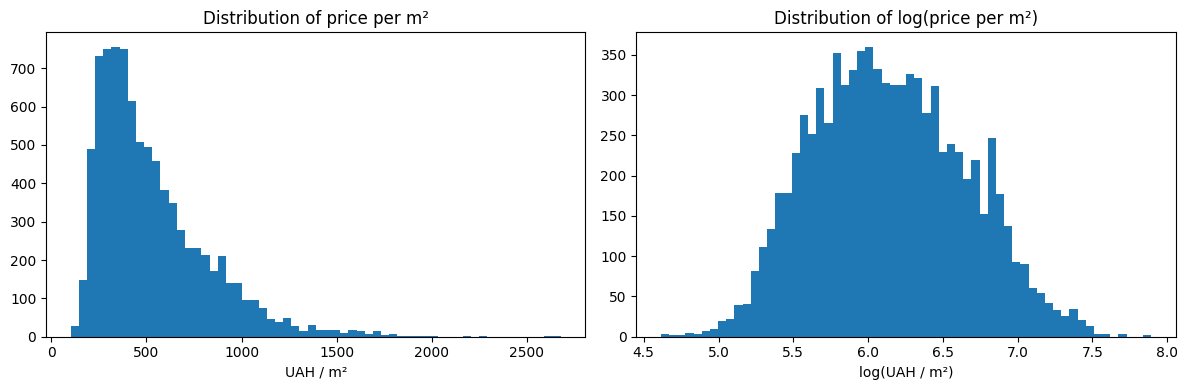

,price_per_sqm,log_price_sqm
count,"8,692.00","8,692.00"
mean,530.20,6.14
std,289.46,0.51
min,101.00,4.62
25%,318.61,5.76
50%,450.00,6.11
75%,666.67,6.50
max,"2,678.57",7.89


In [42]:
# Filter extreme price_per_sqm outliers and create log target
df_sqm = df[
    (df["price_per_sqm"] > 100) &
    (df["price_per_sqm"] < 10_000)
].copy()
df_sqm["log_price_sqm"] = np.log(df_sqm["price_per_sqm"])

print("Rows for price_per_sqm model:", len(df_sqm))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_sqm["price_per_sqm"], bins=60)
axes[0].set_title("Distribution of price per m²")
axes[0].set_xlabel("UAH / m²")

axes[1].hist(df_sqm["log_price_sqm"], bins=60)
axes[1].set_title("Distribution of log(price per m²)")
axes[1].set_xlabel("log(UAH / m²)")

plt.tight_layout()
plt.show()

df_sqm[["price_per_sqm", "log_price_sqm"]].describe()

In [43]:
sqm_data = df_sqm[features + ["price_per_sqm", "log_price_sqm"]].copy()
X_sqm = sqm_data[features]
y_sqm = sqm_data["log_price_sqm"]

X_train_sqm, X_test_sqm, y_train_sqm, y_test_sqm = train_test_split(
    X_sqm, y_sqm, test_size=0.20, random_state=RANDOM_STATE
)

preprocessor_sqm = sklearn_clone(preprocessor)

results_sqm = []
fitted_sqm_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", sklearn_clone(preprocessor_sqm)),
        ("model", sklearn_clone(model))
    ])
    pipe.fit(X_train_sqm, y_train_sqm)

    train_pred = pipe.predict(X_train_sqm)
    test_pred  = pipe.predict(X_test_sqm)

    train_pred_uah = np.exp(train_pred)
    test_pred_uah  = np.exp(test_pred)
    train_true_uah = np.exp(y_train_sqm)
    test_true_uah  = np.exp(y_test_sqm)

    results_sqm.append({
        "Model": name,
        "Train RMSE (UAH/m²)": np.sqrt(mean_squared_error(train_true_uah, train_pred_uah)),
        "Test RMSE (UAH/m²)":  np.sqrt(mean_squared_error(test_true_uah, test_pred_uah)),
        "Train MAE (UAH/m²)":  mean_absolute_error(train_true_uah, train_pred_uah),
        "Test MAE (UAH/m²)":   mean_absolute_error(test_true_uah, test_pred_uah),
        "Train R² (log)": r2_score(y_train_sqm, train_pred),
        "Test R² (log)":  r2_score(y_test_sqm,  test_pred),
    })
    fitted_sqm_pipelines[name] = pipe

results_sqm_df = pd.DataFrame(results_sqm).sort_values("Test RMSE (UAH/m²)")
print("=== Model results — target: log(price per m²) ===")
results_sqm_df

=== Model results — target: log(price per m²) ===


,Model,Train RMSE (UAH/m²),Test RMSE (UAH/m²),Train MAE (UAH/m²),Test MAE (UAH/m²),Train R² (log),Test R² (log)
4,GB_Var1_Slow,100.29,157.03,66.72,103.47,0.90,0.74
2,RF_Best_Base,64.71,157.12,39.07,102.15,0.97,0.73
3,RF_Var1_More_Trees_Reg,78.53,157.94,45.18,102.39,0.95,0.73
5,XGB_Var1_Slow_Deep,102.73,157.99,66.73,103.92,0.90,0.73
1,Ridge Regression,212.89,219.39,140.03,141.12,0.58,0.54
0,Linear Regression,212.92,219.41,140.02,141.11,0.58,0.54


In [44]:
# Permutation importance for the best price_per_sqm model
best_sqm_name = results_sqm_df.iloc[0]["Model"]
best_sqm_pipe = fitted_sqm_pipelines[best_sqm_name]
print("Best model (price_per_sqm):", best_sqm_name)

perm_sqm = permutation_importance(
    best_sqm_pipe,
    X_test_sqm,
    y_test_sqm,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2"
)

importance_sqm_df = pd.DataFrame({
    "feature": X_test_sqm.columns,
    "importance_mean": perm_sqm.importances_mean,
    "importance_std":  perm_sqm.importances_std,
}).sort_values("importance_mean", ascending=False)

# Side-by-side comparison with log_price importances
comparison = (
    importance_df[["feature", "importance_mean"]]
    .rename(columns={"importance_mean": "log_price"})
    .merge(
        importance_sqm_df[["feature", "importance_mean"]].rename(columns={"importance_mean": "price_per_sqm"}),
        on="feature"
    )
    .sort_values("price_per_sqm", ascending=False)
)
print("\nFeature importance comparison (decrease in R²):")
print(comparison.to_string(index=False))

# Bar chart for price_per_sqm top 10
top_sqm = importance_sqm_df.head(10).sort_values("importance_mean")
plt.figure(figsize=(8, 5))
plt.barh(top_sqm["feature"], top_sqm["importance_mean"],
         xerr=top_sqm["importance_std"], capsize=3)
plt.title(f"Top 10 Feature Importances: {best_sqm_name}\n(target: log price per m²)")
plt.xlabel("Permutation importance, decrease in R²")
plt.tight_layout()
plt.show()

Best model (price_per_sqm): GB_Var1_Slow


KeyboardInterrupt: 

### Interpretation: Price per m² Models

**What changes when we switch targets:**

When we model `log(price_per_sqm)` instead of `log(price_uah)`, apartment size (`area_total`) is baked into the target and can no longer act as the dominant predictor. This forces the models to explain *why some locations and buildings command a premium per square metre*.

**Expected R² drop:** The R² for `price_per_sqm` models will typically be lower than for `log_price` models, because the strongest predictor (size) has been divided out. This is not a failure — it reflects that rent per m² is genuinely harder to predict from observable features alone.

**Features that become more important:**
- Location quality: `drive_time_maidan_car_min`, `dist_metro_km`, `bank_side`
- Building quality: `construction_tech`, `building_age`
- Floor position: `floor_ratio`, `is_last_floor`

**Practical interpretation:**
A model for `price_per_sqm` is useful for answering: *"Is this apartment overpriced or underpriced for its location and building type?"* A model for total `price_uah` is useful for budget planning. Both are informative; the choice depends on the use case.

**Comparison summary:**

| | `log_price` model | `log(price/m²)` model |
|---|---|---|
| **What it predicts** | Total monthly rent | Rent density per m² |
| **Dominant predictor** | Apartment size | Location, building quality |
| **Expected R²** | Higher | Lower (size removed) |
| **Best use case** | Tenant budget planning | Detecting over/underpriced listings |

## 12. Contribution Statement Template

Replace this section with your actual team contribution statement.

- **Student 1:** data collection, data cleaning, EDA, notebook documentation.
- **Student 2:** model development, model evaluation, interpretation, presentation preparation.

Both team members reviewed the final notebook, results, and presentation.